## Importing Libraries and Loading Datasets

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [30]:
sns.set_style('white')

In [31]:
deaths = pd.read_csv('number-of-deaths.csv')
pop = pd.read_csv('population.csv')
gdp = pd.read_csv('gdp-per-capita-maddison-project-database.csv')
life_exp = pd.read_csv('life-expectancy-unwpp.csv')
income = pd.read_csv('daily-median-income.csv')

In [32]:
# Renaming key columns in each dataset
deaths = deaths.rename(columns = {'Number of deaths, total':'deaths'})
pop = pop.rename(columns = {'Population':'population'})
gdp = gdp.rename(columns = {'GDP':'gdp_per_capita'})
life_exp = life_exp.rename(columns = {'Life Expectancy':'life_exp'})

In [33]:
for df in (deaths, pop, gdp, life_exp, income):
    df.columns = df.columns.str.lower()

In [34]:
# Merging datasets into one df
df = deaths.merge(pop, on = ['entity', 'year', 'code'], how = 'inner')\
    .merge(gdp, on = ['entity', 'year', 'code'], how = 'inner')\
    .merge(life_exp, on = ['entity', 'year', 'code'], how = 'inner')

## Data Validation
- The dataset contans 11,545 rows, covering 166 countries and 73 years (1950 - 2022).
- No missing values or duplicated rows

In [35]:
df.head()

,entity,code,year,deaths,population,gdp_per_capita,life_exp
0,Afghanistan,AFG,1950,290972,7776180,1156.0,28.156
1,Afghanistan,AFG,1951,288752,7879343,1170.0,28.584
2,Afghanistan,AFG,1952,288059,7987784,1189.0,29.014
3,Afghanistan,AFG,1953,287712,8096703,1240.0,29.452
4,Afghanistan,AFG,1954,289189,8207954,1245.0,29.698


In [36]:
df.describe()

,year,deaths,population,gdp_per_capita,life_exp
count,11545.000000,1.154500e+04,1.154500e+04,11545.000000,11545.000000
mean,1986.981897,3.869352e+05,3.950924e+07,10431.922325,62.730742
std,20.942012,2.287774e+06,2.620185e+08,13350.938575,12.542164
min,1950.000000,4.020000e+02,2.430400e+04,377.580080,11.295000
25%,1969.000000,2.145100e+04,2.439219e+06,1949.000000,53.422000
50%,1988.000000,7.840600e+04,6.763902e+06,5367.795000,65.609000
75%,2005.000000,2.018480e+05,2.055812e+07,13238.000000,72.477000
max,2022.000000,6.972810e+07,8.021407e+09,160051.230000,85.263000


In [37]:
# Calculating mortality_rate
df['mortality_rate'] = df['deaths']/df['population']
df['mortality_per_1000'] = df['mortality_rate'] * 1000

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.isna().sum()

entity                0
code                  0
year                  0
deaths                0
population            0
gdp_per_capita        0
life_exp              0
mortality_rate        0
mortality_per_1000    0
dtype: int64

In [40]:
df['year'].max() - df['year'].min()

np.int64(72)

In [41]:
df['entity'].nunique()

166

## EDA

### Univariate analysis
- **Year:** The distribution of the `year` variable is approximately uniform, with observations spread fairly evenly from 1950 to 2022. There is no evidence of outliers, and the negative kurtosis indicates a flatter-than-normal distribution, which is expected for a uniformly distributed time variable. This suggests that the dataset has consistent temporal coverage across years, reducing the risk of temporal bias in subsequent analyses. As a result, trends observed in time series analysis are less likely to be driven by uneven sampling across specific periods. 

- **Mortality Rate:** The distribution of `mortality_per_1000` is highly right-skewed. This indicates that while most country-year observations cluster at lower mortality levels, a small subset exhibits substantially higher mortality. These outliers likely correspond to specific periods of crisis or systemic breakdown (such as conflict, famine, or epidemics). 

- **GDP per Capita:** The distribution of `gdp_per_capita` is strongly right-skewed, driven by a small number of very high-income country-year observations. This is expected given the global structure of income, where high-income economies (e.g., United States, Switzerland, Norway) are relatively few compared to the large number of low- and middle-income countries.  

- **Life Expectancy:** `life_exp` is slightly left0-skewed, but the distribution is close to symmetric, and with only a small number of outliers. The small number of outliers suggests that extreme deviations are rare and likely tied to specific historical or crisis-driven contexts rather than widespread noise.

In [42]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - IQR * 1.5
    upper = Q3 + IQR * 1.5

    mask = (series < lower)|(series > upper)
    return series[mask]

def univariate_analysis(df, col):
    data = df[col].dropna()

    print(f"\n--- Summary stats for {col} ---")

    # Summary stats
    print(f'Mean: {data.mean():.2f}')
    print(f'Median: {data.median():.2f}')
    print(f'Std Dev: {data.std():.2f}')
    print(f'Skewness: {data.skew():.2f}')
    print(f'Kurtosis: {data.kurtosis():.2f}')
 
    # Outlier detection
    outliers = detect_outliers(data)
    print(f"Outliers: {len(outliers)} ({100 * len(outliers)/len(data):.2f}%)")

    # Visualization
    fig, axes = plt.subplots(1,2, figsize = (10,5))
    fig.suptitle(f'Distribution of {col}', fontsize = 12)

    # Histogram
    sns.histplot(x = data, kde = True, edgecolor = 'black', alpha = 0.7, ax = axes[0])
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Histogram')
    axes[0].axvline(data.mean(), color = 'red', label = 'Mean', linewidth = 1)
    axes[0].axvline(data.median(), color = 'green', linestyle = '--', label = 'Median', linewidth = 1)
    axes[0].legend()
    
    # Box plot
    sns.boxplot(y = data, ax = axes[1])
    axes[1].set_ylabel(col)
    axes[1].set_title('Box plot')

    plt.tight_layout()
    plt.show()


--- Summary stats for year ---
Mean: 1986.98
Median: 1988.00
Std Dev: 20.94
Skewness: -0.06
Kurtosis: -1.18
Outliers: 0 (0.00%)


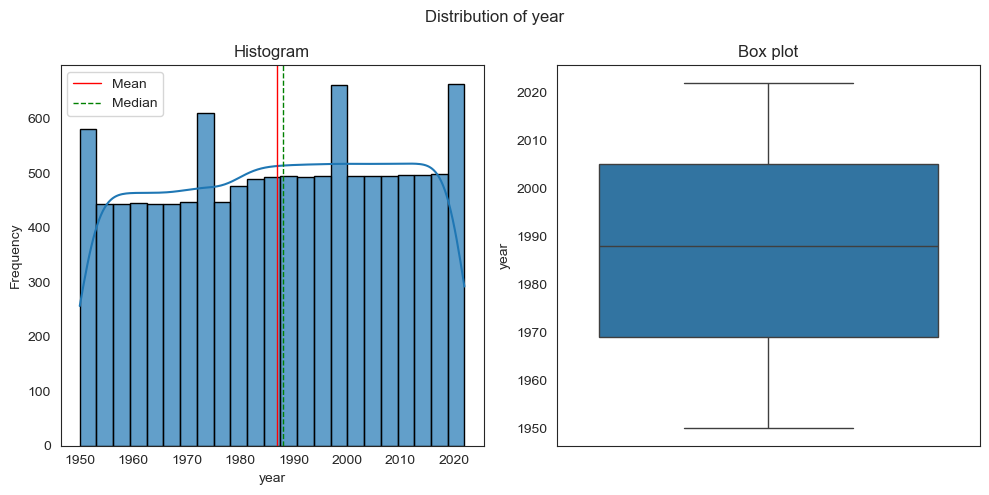


--- Summary stats for mortality_per_1000 ---
Mean: 11.72
Median: 9.87
Std Dev: 6.54
Skewness: 2.64
Kurtosis: 28.16
Outliers: 602 (5.21%)


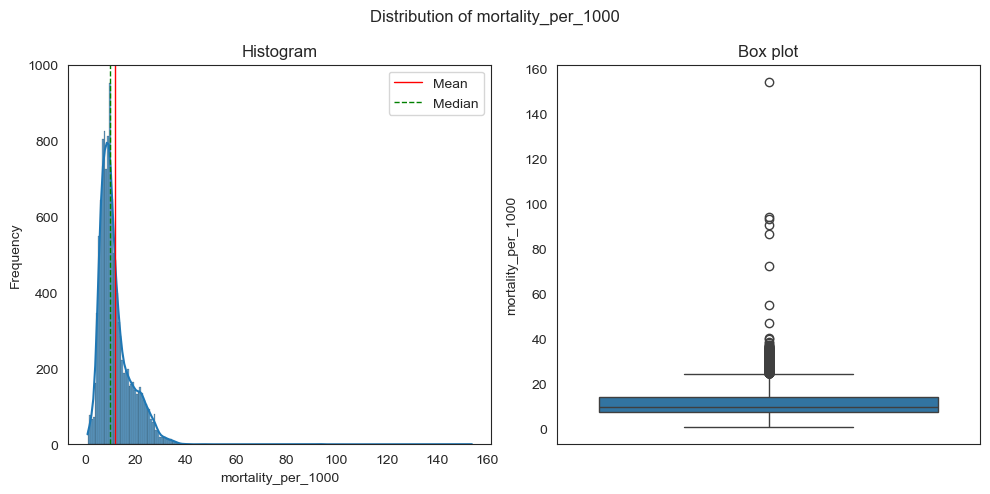


--- Summary stats for gdp_per_capita ---
Mean: 10431.92
Median: 5367.80
Std Dev: 13350.94
Skewness: 3.16
Kurtosis: 18.41
Outliers: 970 (8.40%)


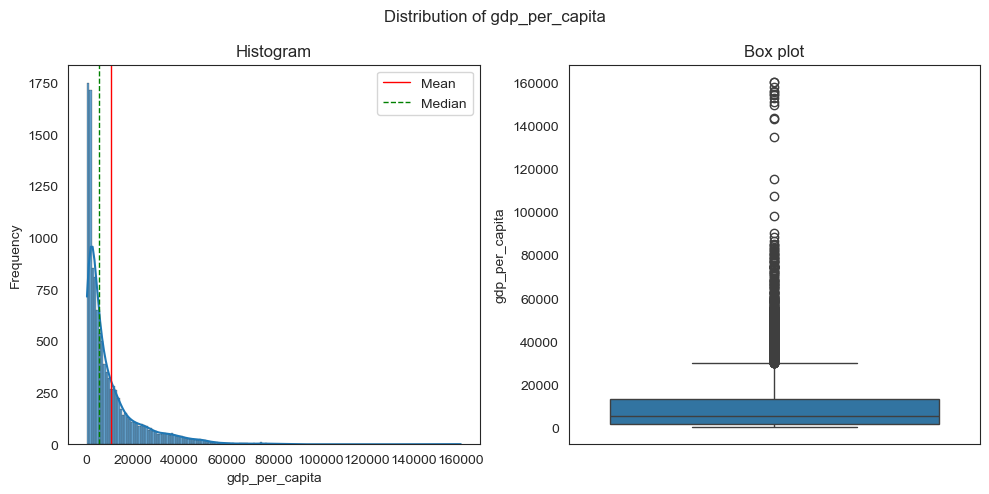


--- Summary stats for life_exp ---
Mean: 62.73
Median: 65.61
Std Dev: 12.54
Skewness: -0.55
Kurtosis: -0.57
Outliers: 8 (0.07%)


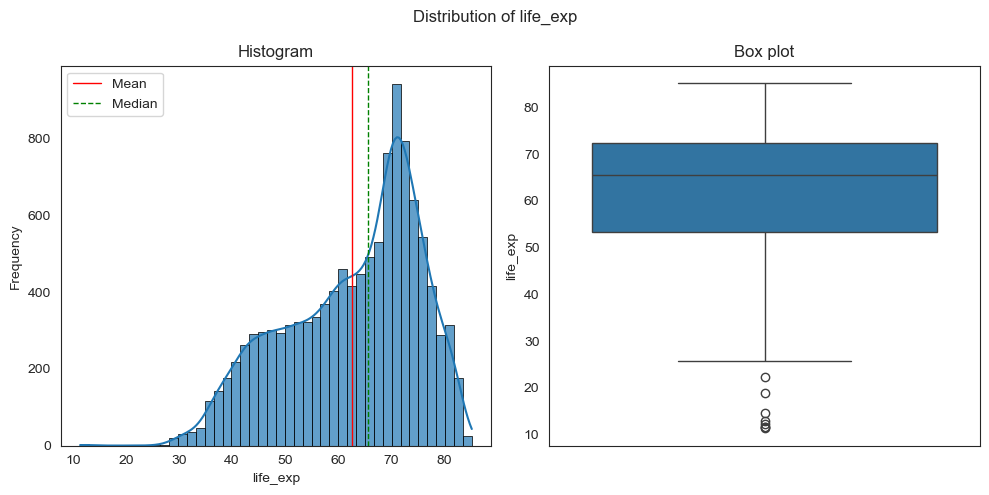

In [43]:
numeric_cols = ['year', 'mortality_per_1000', 'gdp_per_capita', 'life_exp']

for col in numeric_cols:
    univariate_analysis(df, col)


--- Summary stats for log_mortality_per_1000 ---
Mean: 2.33
Median: 2.29
Std Dev: 0.52
Skewness: -0.19
Kurtosis: 1.01
Outliers: 164 (1.42%)


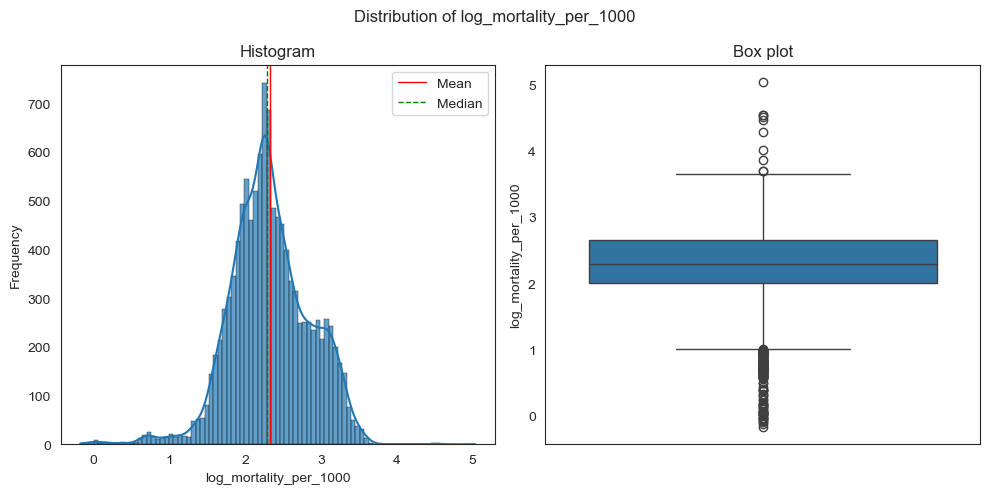


--- Summary stats for log_population ---
Mean: 15.70
Median: 15.73
Std Dev: 1.78
Skewness: -0.07
Kurtosis: 0.54
Outliers: 367 (3.18%)


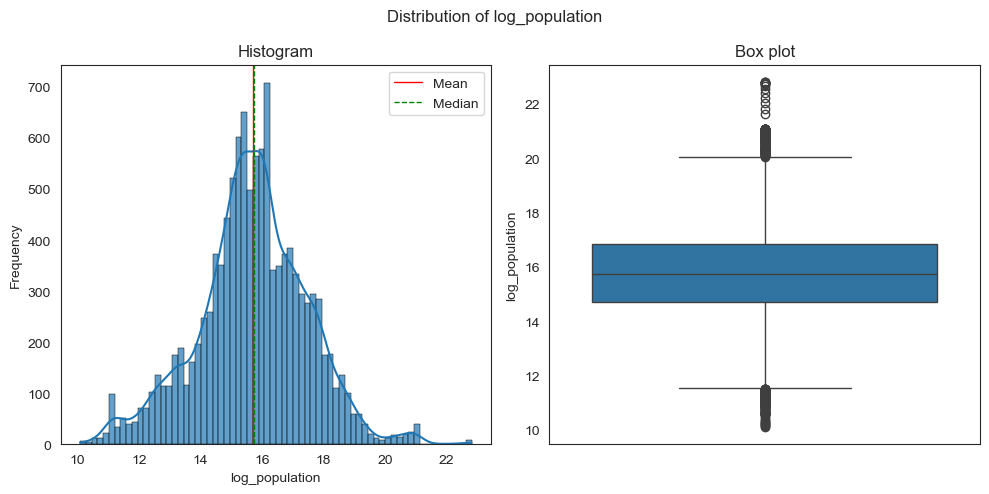


--- Summary stats for log_gdp_per_capita ---
Mean: 8.59
Median: 8.59
Std Dev: 1.18
Skewness: 0.11
Kurtosis: -0.91
Outliers: 0 (0.00%)


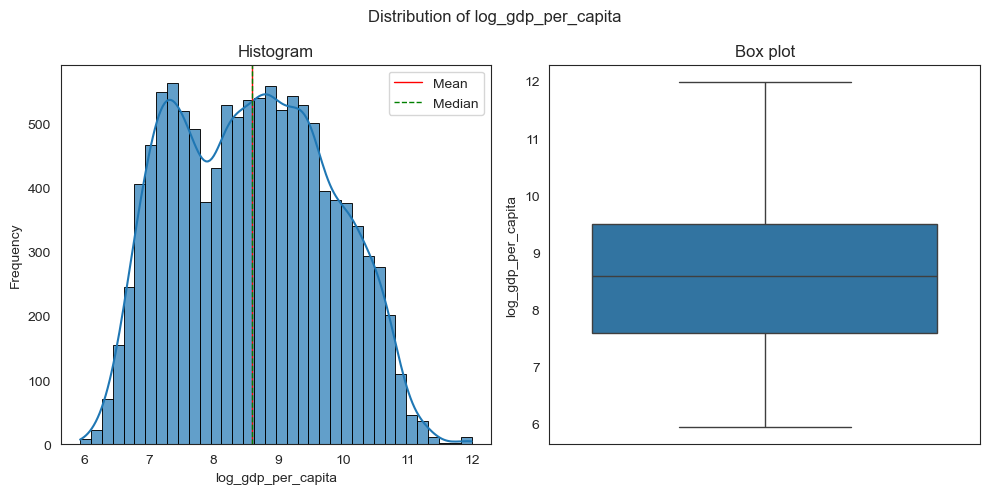

In [44]:
for col in ['mortality_per_1000', 'population', 'gdp_per_capita']:
    log_col = 'log_' + col
    df[log_col] = np.log(df[col])

    univariate_analysis(df, log_col)

### Extreme Mortality and Life Expectancy Observations
**Historically**, the most extreme observations show a clear convergence of very high mortality rates and very low life expectancy, concentrated in a small number of country-year periods driven by systemic disruption.

The most severe cases, Cambodia (1975–1978) and Rwanda (1994), reflect periods of genocide and state collapse, where mortality spikes coincide with life expectancy dropping to near-minimal levels (~11–12 years).

A second group, including the Central African Republic (CAR), Burundi, Bangladesh, and early-period South Korea, reflects sustained instability, conflict exposure, or historically low baseline development. Within this group, the Central African Republic is particularly notable as it recorded high mortality values in recent years (2009 and 2022). The 2009 period reflects a fragile post-conflict setting with continued armed group activity and weak state control, resulting in persistently elevated mortality. By 2022, mortality remains high under conditions of ongoing civil war, fragmented territorial control, and repeated cycles of violence and displacement.

In [45]:
# Lowest mortality rate historically
df.sort_values(by = 'mortality_per_1000', ascending = False).head(10)

,entity,code,year,deaths,population,gdp_per_capita,life_exp,mortality_rate,mortality_per_1000,log_mortality_per_1000,log_population,log_gdp_per_capita
8884,Rwanda,RWA,1994,1045769,6792358,707.29710,12.158,0.153963,153.962586,5.036710,15.731309,6.561451
1545,Cambodia,KHM,1978,489494,5211654,1291.00000,11.573,0.093923,93.922966,4.542475,15.466408,7.163172
1544,Cambodia,KHM,1977,527082,5668561,1143.00000,11.295,0.092983,92.983387,4.532421,15.550446,7.041412
1543,Cambodia,KHM,1976,555801,6134989,1025.00000,11.632,0.090595,90.595272,4.506402,15.629519,6.932448
1542,Cambodia,KHM,1975,569757,6581373,925.00000,12.784,0.086571,86.571146,4.460967,15.699754,6.829794
1868,Central African Republic,CAF,2009,328277,4529051,898.70050,14.665,0.072483,72.482513,4.283345,15.326023,6.800950
1881,Central African Republic,CAF,2022,281036,5098038,596.39300,18.818,0.055126,55.126305,4.009627,15.444366,6.390900
9677,South Korea,KOR,1950,931034,19757319,998.08875,22.226,0.047123,47.123499,3.852772,16.799035,6.905842
1466,Burundi,BDI,1972,145990,3617134,866.00000,25.777,0.040361,40.360683,3.697856,15.101193,6.763885
693,Bangladesh,BGD,1971,2802344,70276757,934.00000,26.522,0.039876,39.875830,3.685770,18.067952,6.839476


In [46]:
# Lowest life expectancies historically
df.sort_values(by = 'life_exp', ascending = True).head(10)

,entity,code,year,deaths,population,gdp_per_capita,life_exp,mortality_rate,mortality_per_1000,log_mortality_per_1000,log_population,log_gdp_per_capita
1544,Cambodia,KHM,1977,527082,5668561,1143.00000,11.295,0.092983,92.983387,4.532421,15.550446,7.041412
1545,Cambodia,KHM,1978,489494,5211654,1291.00000,11.573,0.093923,93.922966,4.542475,15.466408,7.163172
1543,Cambodia,KHM,1976,555801,6134989,1025.00000,11.632,0.090595,90.595272,4.506402,15.629519,6.932448
8884,Rwanda,RWA,1994,1045769,6792358,707.29710,12.158,0.153963,153.962586,5.036710,15.731309,6.561451
1542,Cambodia,KHM,1975,569757,6581373,925.00000,12.784,0.086571,86.571146,4.460967,15.699754,6.829794
1868,Central African Republic,CAF,2009,328277,4529051,898.70050,14.665,0.072483,72.482513,4.283345,15.326023,6.800950
1881,Central African Republic,CAF,2022,281036,5098038,596.39300,18.818,0.055126,55.126305,4.009627,15.444366,6.390900
9677,South Korea,KOR,1950,931034,19757319,998.08875,22.226,0.047123,47.123499,3.852772,16.799035,6.905842
1466,Burundi,BDI,1972,145990,3617134,866.00000,25.777,0.040361,40.360683,3.697856,15.101193,6.763885
693,Bangladesh,BGD,1971,2802344,70276757,934.00000,26.522,0.039876,39.875830,3.685770,18.067952,6.839476


#### Recent Mortality Burden
The distribution of 10-year median mortality rates (2012 - 2022), shows both the level and stability of mortality across countries.

At the lower end, countries such as Qatar, United Arab Emirates, Kuwait, Bahrain, Oman, and Saudi Arabia exhibit very low median mortality rates with narrow IQRs. This indicates not only low mortality burden but also high temporal stability, with little year-to-year fluctuation. Similar patterns are observed in Jordan, Palestine, Singapore, and Honduras, though at slightly higher median levels. Overall, this group represents structurally stable, low-mortality environments.

At the higher end, countries such as Bulgaria, Latvia, Lithuania, Serbia, Ukraine, Romania, Croatia, and Hungary display consistently elevated median mortality rates. Their IQRs are generally modest, suggesting that high mortality is persistent rather than driven by short-term shocks. This points to underlying structural or demographic factors maintaining higher baseline mortality levels. Chad occupies a similar high-mortality position but with a wider IQR, indicating greater variability over time.  

The most notable case is the **Central African Republic**, which combines a high median mortality rate with an exceptionally large IQR. This reflects substantial instability, where periods of relatively lower mortality are interspersed with severe spikes, consistent with recurring crises or systemic disruptions.

In [83]:
recent_df = df[df['year'] >= (df['year'].max() - 10)]

avg_mortality_recent = recent_df.groupby('entity')['mortality_per_1000'].agg(
    median = 'median',
    q1 = lambda x: x.quantile(0.25),
    q3 = lambda x: x.quantile(0.75)
    ).reset_index()

In [85]:
avg_mortality_recent['iqr'] = avg_mortality_recent['q3'] - avg_mortality_recent['q1']

avg_mortality_recent.head()

,entity,median,q1,q3,iqr
0,Afghanistan,7.510522,7.293345,7.580997,0.287652
1,Albania,7.374118,7.240134,8.090936,0.850802
2,Algeria,4.654179,4.645550,4.674099,0.028548
3,Angola,8.191908,7.664467,8.994224,1.329757
4,Argentina,7.718922,7.629540,8.157483,0.527943


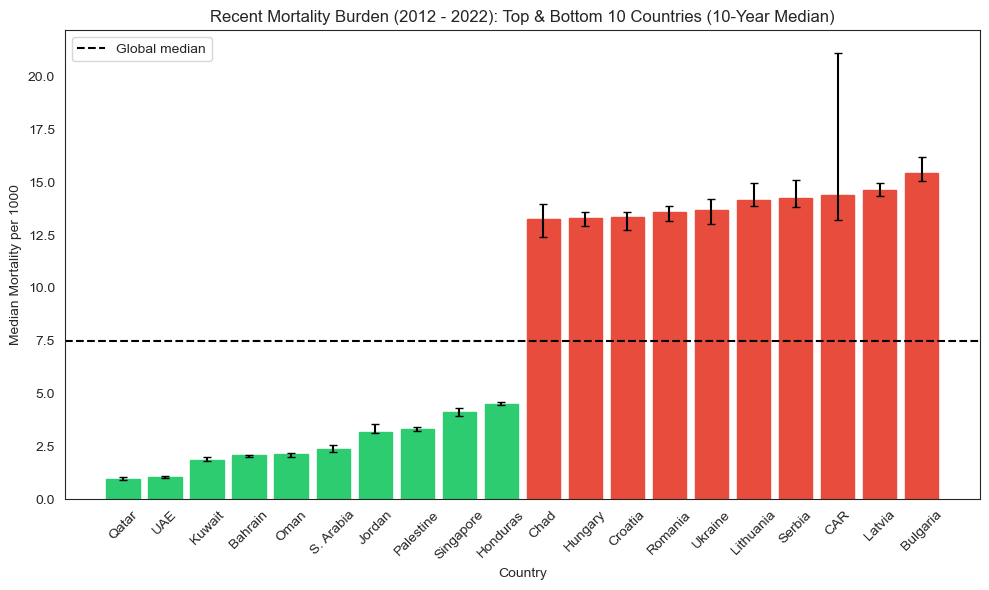

In [91]:
top_10 = avg_mortality_recent.sort_values('median', ascending=False).head(10)
bottom_10 = avg_mortality_recent.sort_values('median', ascending=True).head(10)

combined = pd.concat([bottom_10, top_10])
combined = combined.sort_values('median', ascending=True)

global_median = avg_mortality_recent['median'].median()

plt.figure(figsize=(10,6))

combined['color'] = combined['median'].apply(
    lambda x: "#2ECC71" if x < global_median else "#E74C3C"
)

combined['upper'] = combined['q3'] - combined['median']
combined['lower'] = combined['median'] - combined['q1']

sns.barplot(data = combined.replace({'United Arab Emirates':'UAE', 'Central African Republic': 'CAR', 'Saudi Arabia': 'S. Arabia'}), 
            x = 'entity', y = 'median')
plt.errorbar(x = range(len(combined)), y = combined['median'], yerr = [combined['lower'], combined['upper']],
             fmt = 'none', c = 'black', capsize = 3)

for i, bar in enumerate(plt.gca().patches):
    bar.set_color(combined['color'].iloc[i])

plt.axhline(global_median, color = 'black', linestyle = '--', linewidth = 1.5, label = 'Global median')
plt.xticks(rotation = 45)
plt.xlabel('Country')
plt.ylabel('Median Mortality per 1000')
plt.title(f"Recent Mortality Burden ({recent_df['year'].min()} - {recent_df['year'].max()}): Top & Bottom 10 Countries (10-Year Median)")
plt.legend()

plt.tight_layout()
plt.show()

## Time Series Analysis

In [50]:
def time_series_analysis(df, entity, metrics):
    entity_df = df[df['entity'] == entity].sort_values('year').copy()

    if len(entity_df) == 0:
        print(f'No data for {entity}')
        return
    
    print(f"TIME SERIES: {entity}")
    print(f"{'-'*60}")

    fig, axes = plt.subplots(len(metrics), 1, figsize = (10, 5 * len(metrics)))
    if len(metrics) == 1:
        axes = [axes]
    
    for idx, metric in enumerate(metrics):
        # Calculate year-on-year change
        entity_df[f'{metric}_yoy_change'] = entity_df[metric].pct_change() * 100

        # Plot trend
        sns.lineplot(data = entity_df, x = 'year', y = metric, marker = 'o', linewidth = 2, markersize = 6, ax = axes[idx])
        axes[idx].set_xlabel('Year')
        axes[idx].set_ylabel(metric)
        axes[idx].set_title(f'{metric} trend')

        # Add Trend line
        valid = entity_df[['year', metric]].dropna()
        z = np.polyfit(valid['year'], valid[metric], 1)
        p = np.poly1d(z)
        axes[idx].plot(valid['year'], p(valid['year']), linestyle = '--', color = 'red', alpha = 0.7, label = f'Trend: {z[0]:.2f}/year')
        axes[idx].legend()

        # Print statistics
        print(f'\n{metric}')
        print(f"Starting value ({entity_df['year'].min()}): {entity_df[metric].iloc[0]:.2f}")
        print(f"Ending value({entity_df['year'].max()}): {entity_df[metric].iloc[-1]:.2f}")
        print(f"Total change: {entity_df[metric].iloc[-1] - entity_df[metric].iloc[0]:.2f}")
        print(f"Avg YoY change: {entity_df[f'{metric}_yoy_change'].mean():.2f}%")

    plt.tight_layout()
    plt.show()

TIME SERIES: Nigeria
------------------------------------------------------------

mortality_rate
Starting value (1950): 0.03
Ending value(2022): 0.01
Total change: -0.02
Avg YoY change: -1.15%

gdp_per_capita
Starting value (1950): 1200.00
Ending value(2022): 5070.49
Total change: 3870.49
Avg YoY change: 2.23%

life_exp
Starting value (1950): 35.53
Ending value(2022): 54.08
Total change: 18.55
Avg YoY change: 0.59%


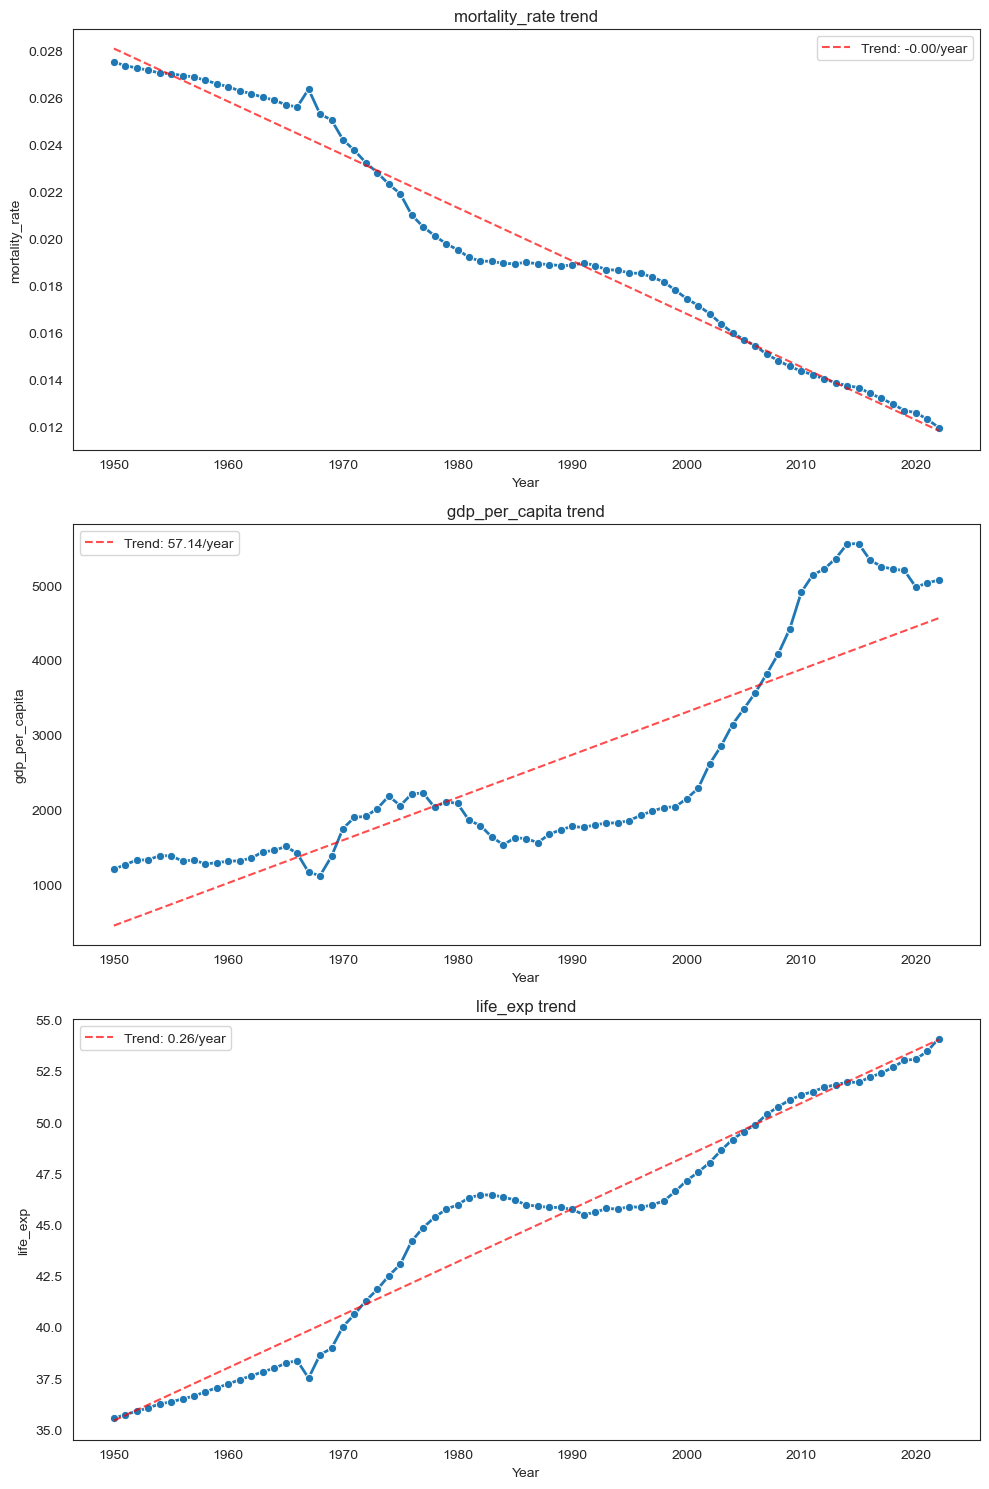

In [92]:
time_series_analysis(df, 'Nigeria', ['mortality_rate', 'gdp_per_capita','life_exp'])

In [95]:
def time_series_analysis(df, entity, metrics):
    entity_df = df[df['entity'] == entity].sort_values('year').copy()

    if len(entity_df) == 0:
        print(f'No data for {entity}')
        return
    
    print(f"TIME SERIES: {entity}")
    print(f"{'-'*60}")

    for metric in metrics:
        entity_df[f'{metric}_yoy_change'] = entity_df[metric].pct_change() * 100

        # Create 2 rows: level + YoY
        fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

        # =========================
        # 1. MAIN METRIC (TOP)
        # =========================
        sns.lineplot(
            data=entity_df,
            x='year',
            y=metric,
            marker='o',
            linewidth=2,
            ax=axes[0],
            color='blue'
        )

        axes[0].set_ylabel(metric)
        axes[0].set_title(f'{metric} Trend')
        axes[0].grid(True, alpha=0.3)

        # Trend line
        valid = entity_df[['year', metric]].dropna()
        if len(valid) > 1:
            z = np.polyfit(valid['year'], valid[metric], 1)
            p = np.poly1d(z)

            axes[0].plot(
                valid['year'],
                p(valid['year']),
                linestyle='--',
                color='red',
                alpha=0.7,
                label=f'Trend: {z[0]:.2f}/year'
            )
            axes[0].legend()

        # =========================
        # 2. YOY CHANGE (BOTTOM)
        # =========================
        axes[1].bar(
            entity_df['year'],
            entity_df[f'{metric}_yoy_change'],
            color='orange',
            alpha=0.6
        )

        axes[1].axhline(0, color='black', linewidth=1)  # baseline
        axes[1].set_ylabel('YoY % change')
        axes[1].set_xlabel('Year')
        axes[1].set_title(f'{metric} Year-on-Year Change')
        axes[1].grid(True, alpha=0.3)

        # =========================
        # PRINT STATS
        # =========================
        print(f'\n{metric}')
        print(f"Starting value ({entity_df['year'].min()}): {entity_df[metric].iloc[0]:.2f}")
        print(f"Ending value ({entity_df['year'].max()}): {entity_df[metric].iloc[-1]:.2f}")
        print(f"Total change: {entity_df[metric].iloc[-1] - entity_df[metric].iloc[0]:.2f}")
        print(f"Avg YoY change: {entity_df[f'{metric}_yoy_change'].mean():.2f}%")

        plt.tight_layout()
        plt.show()

TIME SERIES: Nigeria
------------------------------------------------------------

mortality_rate
Starting value (1950): 0.03
Ending value (2022): 0.01
Total change: -0.02
Avg YoY change: -1.15%


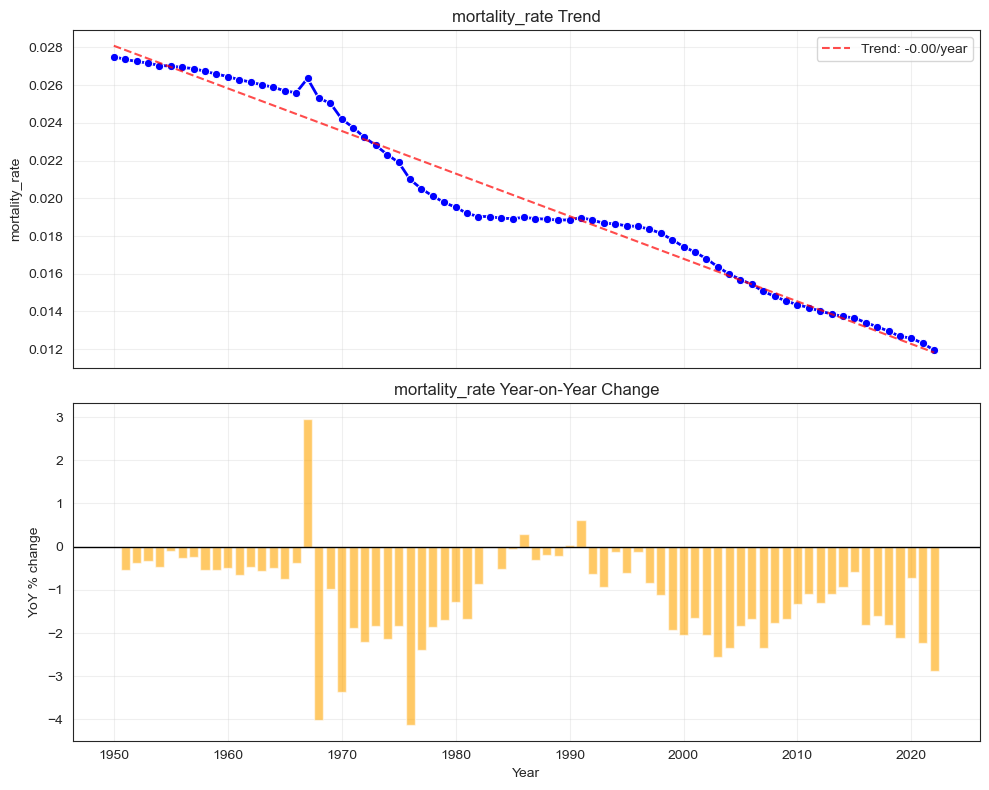


gdp_per_capita
Starting value (1950): 1200.00
Ending value (2022): 5070.49
Total change: 3870.49
Avg YoY change: 2.23%


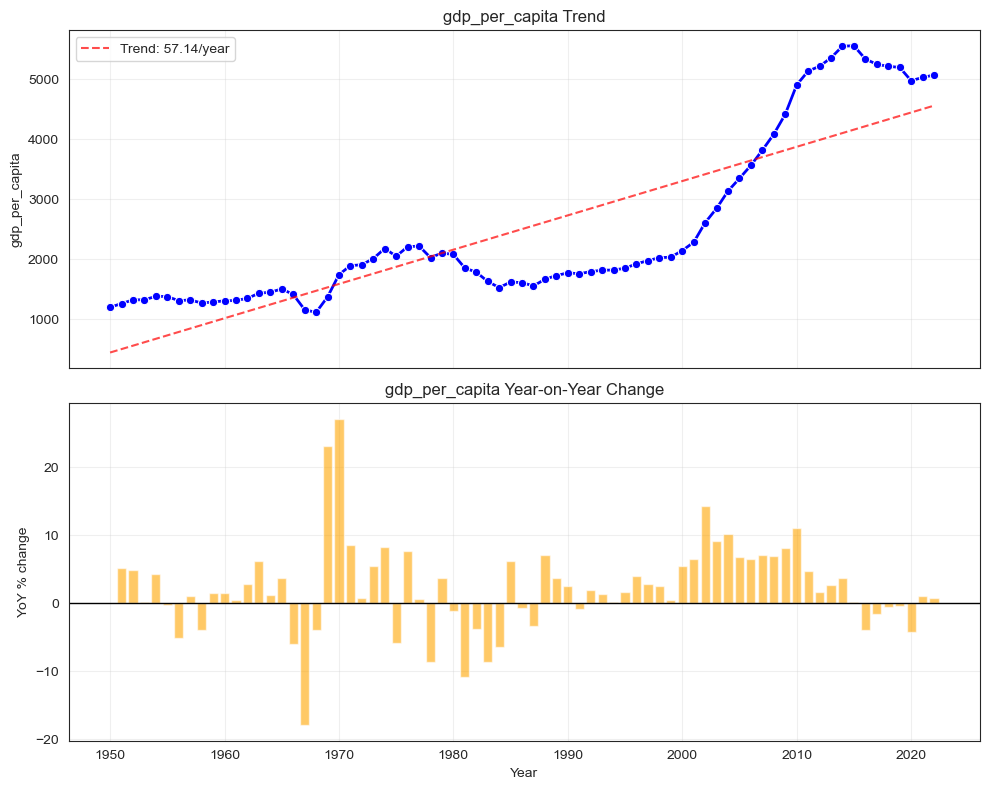


life_exp
Starting value (1950): 35.53
Ending value (2022): 54.08
Total change: 18.55
Avg YoY change: 0.59%


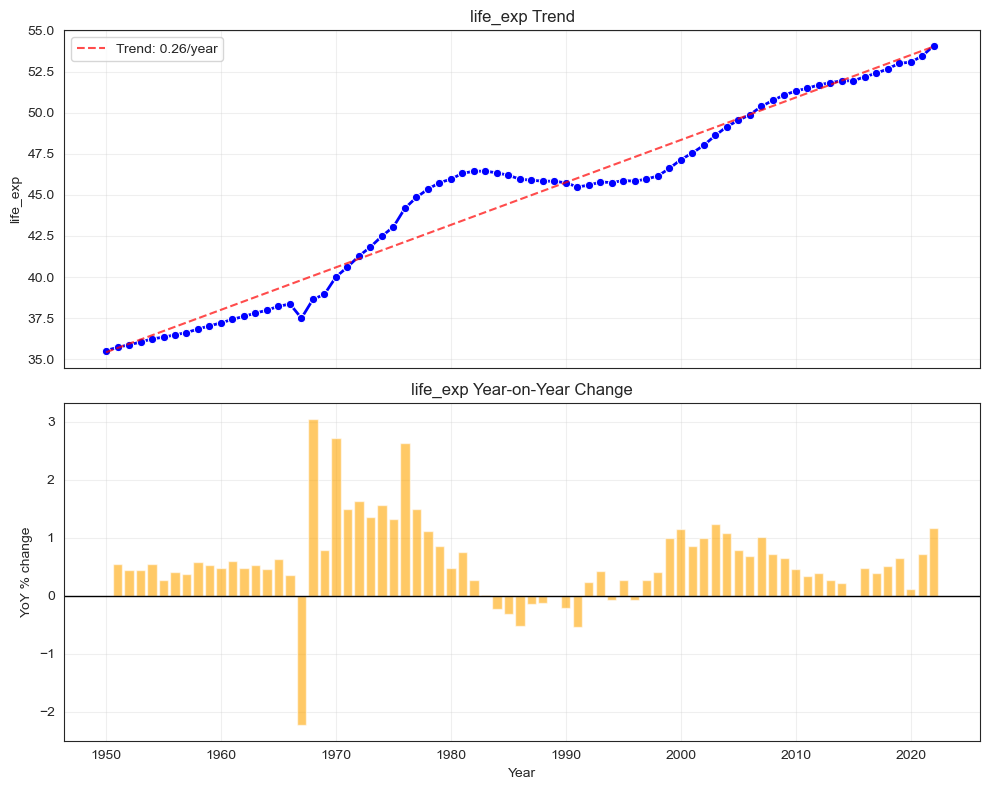

In [96]:
time_series_analysis(df, 'Nigeria', ['mortality_rate', 'gdp_per_capita','life_exp'])